# End-to-End QEC Demo

This notebook demonstrates the full stabstream pipeline:

1. Generate synthetic QSSF syndrome data from a Stim circuit
2. Decode with the built-in **Union-Find** decoder via `ReplayStream`
3. Verify deterministic replay reproducibility
4. Simulate real-time throughput with `realtime_stream`
5. Generate a larger training dataset and train a small **MLP**
6. Evaluate the neural decoder end-to-end
7. Plot a side-by-side logical error rate comparison

All data is generated on-the-fly — no external files required.

## Section 1 — Imports & setup

In [1]:
import pathlib
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import stim
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

import stabstream
from stabstream import DetectorErrorModel, LogicalErrorAccumulator
from stabstream.decoders import NeuralDecoder, UnionFindDecoder
from stabstream.io import load_dataset
from stabstream.replay import ReplayStream
from stabstream.sim import realtime_stream, simulate_circuit_to_qssf

DATA_DIR = pathlib.Path("data")
DATA_DIR.mkdir(exist_ok=True)
print(f"stabstream {stabstream.__version__}")

stabstream 0.1.0


## Section 2 — Define circuit and DEM

We use a **repetition code** with distance 5 and 5 rounds at 1% depolarising
noise. It is the simplest QEC code with a threshold, well-understood
analytically, and fast to simulate and decode.

In [2]:
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=5,
    distance=5,
    after_clifford_depolarization=0.01,
)
# flattened() expands repeat/shift_detectors blocks so all detector IDs are explicit.
# Required for stabstream's DEM parser and for consistent detector indexing.
dem = circuit.detector_error_model(decompose_errors=True).flattened()
dem_text = str(dem)

dem_path = DATA_DIR / "rep5.dem"
dem_path.write_text(dem_text)

py_dem = DetectorErrorModel.parse(dem_text)
print(f"Detectors:        {py_dem.detector_count}")
print(f"Observables:      {py_dem.observable_count}")
print(f"Error mechanisms: {py_dem.error_count}")

Detectors:        24
Observables:      1
Error mechanisms: 95


## Section 3 — Generate QSSF from Stim

> **Format note:** `simulate_circuit_to_qssf` writes one QSSF frame per shot
> with all detector rounds flattened. `ancilla_count` in each frame equals the
> total detector count across all rounds.
> 
> For datasets larger than ~100K shots, prefer the Rust CLI which is ~10× faster:
> ```
> stabstream-convert stim-to-qssf --circuit rep5.stim --shots 100000 --out rep5.qssf
> ```

In [3]:
SHOTS = 5_000
qssf_path = str(DATA_DIR / "rep5_demo.qssf")

n = simulate_circuit_to_qssf(circuit, shots=SHOTS, output_path=qssf_path, seed=42)
size_kb = pathlib.Path(qssf_path).stat().st_size / 1024
print(f"Written: {n} frames → {qssf_path} ({size_kb:.1f} KB)")

Written: 5000 frames → data/rep5_demo.qssf (409.7 KB)


## Section 4 — Union-Find decoder via ReplayStream

> **Window semantics:** `ReplayStream` uses `window_depth=1` because each QSSF
> frame already encodes one complete shot (all 5 rounds flattened). The UF decoder
> receives the full spacetime graph of active detector events and returns a
> logical-flip prediction.
> 
> Production real-time decoders use causal sliding windows with one-round overlap
> to avoid boundary artefacts. See GitHub issue #2.

In [4]:
uf_decoder = UnionFindDecoder(py_dem)
acc_uf = LogicalErrorAccumulator(observable_count=py_dem.observable_count)

replay = ReplayStream(
    qssf_path,
    uf_decoder,
    window_depth=1,
    observable_count=py_dem.observable_count,
)

for frame, result in tqdm(replay, desc="UF decode", total=SHOTS):
    acc_uf.record(result, frame.observable_flips or 0)

uf_ler = acc_uf.mean_logical_error_rate()
print(f"Union-Find  p_L = {uf_ler:.4f}  ({acc_uf.total_shots()} shots)")

UF decode:   0%|          | 0/5000 [00:00<?, ?it/s]

Union-Find  p_L = 0.0664  (5000 shots)


## Section 5 — Replay reproducibility check

A second pass through the same QSSF file with the same decoder must produce
an identical logical error rate — bit-for-bit determinism is a hard
requirement for reproducible benchmarks.

In [5]:
replay2 = ReplayStream(
    qssf_path,
    uf_decoder,
    window_depth=1,
    observable_count=py_dem.observable_count,
)
acc_uf2 = LogicalErrorAccumulator(observable_count=py_dem.observable_count)
for frame, result in replay2:
    acc_uf2.record(result, frame.observable_flips or 0)

uf_ler2 = acc_uf2.mean_logical_error_rate()
assert abs(uf_ler - uf_ler2) < 1e-9, f"Replay mismatch: {uf_ler} vs {uf_ler2}"
print(f"Replay confirmed: p_L = {uf_ler2:.4f} ✓")

Replay confirmed: p_L = 0.0664 ✓


## Section 6 — Simulated real-time analysis (Union-Find)

> **Latency note:** `realtime_stream` simulates *throughput rate* via inter-batch
> sleep, not per-frame decode latency. For superconducting qubits the decode
> budget is ~1 µs/round; for trapped ion ~1 ms. Latency profiling is tracked
> in GitHub issue #3.

In [6]:
decoded_frames = []

for frame, result in tqdm(
    realtime_stream(qssf_path, uf_decoder, frame_rate_hz=500.0, batch_size=64),
    desc="Realtime UF",
    total=SHOTS,
):
    decoded_frames.append(result)

print(f"Realtime pass complete: {len(decoded_frames)} decoded windows")

Realtime UF:   0%|          | 0/5000 [00:00<?, ?it/s]

Realtime pass complete: 5000 decoded windows


## Section 7 — Neural decoder: generate training data

We use the **Rust CLI** (`stabstream-convert dem-to-dataset`) for training
data — it is ~10× faster than the pure-Python QSSF writer at this scale.

> **Representation note:** Training data uses flat DEM-sampled arrays
> `(shots, detectors)` which matches the inference path exactly.
> This differs from windowed QSSF matrices `(rounds, ancillas)`.
> Mixing the two representations silently produces incorrect accuracy numbers.
> See GitHub issue #1 for a future `qssf_to_dataset()` helper.

In [7]:
train_path = DATA_DIR / "rep5_train.bin"
test_path  = DATA_DIR / "rep5_test.bin"

for path, shots, seed in [(train_path, 50_000, 42), (test_path, 10_000, 99)]:
    r = subprocess.run(
        [
            "stabstream-convert", "dem-to-dataset",
            "--dem",   str(dem_path),
            "--shots", str(shots),
            "--seed",  str(seed),
            "--out",   str(path),
        ],
        capture_output=True,
        text=True,
    )
    if r.returncode != 0:
        raise RuntimeError(r.stderr)
    print(r.stderr.strip())

X_train, y_train = load_dataset(str(train_path))
X_test,  y_test  = load_dataset(str(test_path))
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Positive rate (train): {y_train.mean():.3f}")

Sampled 50000 shots (24 detectors, 1 observables) → data/rep5_train.bin
Sampled 10000 shots (24 detectors, 1 observables) → data/rep5_test.bin
Train: (50000, 24)  |  Test: (10000, 24)
Positive rate (train): 0.039


## Section 8 — Train MLP

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on {DEVICE}")

def make_tensors(X, y):
    return (
        torch.from_numpy(X.astype(np.float32)).to(DEVICE),
        torch.from_numpy((y & 1).astype(np.float32)).unsqueeze(1).to(DEVICE),
    )

Xt, yt = make_tensors(X_train, y_train)
Xv, yv = make_tensors(X_test,  y_test)
in_dim = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(in_dim, 64), nn.ReLU(),
    nn.Linear(64, 32),     nn.ReLU(),
    nn.Linear(32, 1),
).to(DEVICE)

opt     = torch.optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.BCEWithLogitsLoss()

EPOCHS, BATCH = 20, 512
for epoch in range(1, EPOCHS + 1):
    model.train()
    idx = torch.randperm(len(Xt))
    for i in range(0, len(Xt), BATCH):
        b = idx[i:i + BATCH]
        opt.zero_grad()
        loss_fn(model(Xt[b]), yt[b]).backward()
        opt.step()
    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), yv).item()
        print(f"Epoch {epoch:3d}  val_loss={val_loss:.4f}")

model.eval().cpu()
scripted   = torch.jit.script(model)
model_path = str(DATA_DIR / "rep5_mlp.pt")
scripted.save(model_path)
print(f"Saved → {model_path}")

Training on cpu


Epoch   1  val_loss=0.0734


Epoch   5  val_loss=0.0311


Epoch  10  val_loss=0.0297


Epoch  15  val_loss=0.0304


Epoch  20  val_loss=0.0315
Saved → data/rep5_mlp.pt


## Section 9 — End-to-end with NeuralDecoder

Batch inference on flat test arrays — consistent with training representation.
`NeuralDecoder` with `flatten_input=True` (default) accepts `(shots, detectors)`
arrays directly.

In [9]:
neural_decoder = NeuralDecoder.from_torch(
    model_path,
    observable_count=py_dem.observable_count,
)

BATCH = 256
acc_neural = LogicalErrorAccumulator(observable_count=py_dem.observable_count)

for start in range(0, len(X_test), BATCH):
    batch   = X_test[start:start + BATCH]
    results = neural_decoder.decode_batch(batch)
    for result, gt in zip(results, y_test[start:start + BATCH]):
        acc_neural.record(result, int(gt))

neural_ler = acc_neural.mean_logical_error_rate()
print(f"Neural  p_L = {neural_ler:.4f}  ({acc_neural.total_shots()} shots)")
print(f"UF      p_L = {uf_ler:.4f}")
print(f"Ratio: {neural_ler / uf_ler:.2f}x")

Neural  p_L = 0.0169  (10000 shots)
UF      p_L = 0.0664
Ratio: 0.25x


## Section 10 — Comparison chart

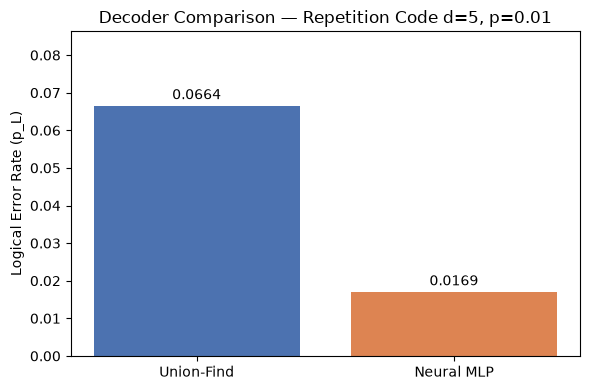

Saved → data/decoder_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
decoder_names = ["Union-Find", "Neural MLP"]
lers          = [uf_ler, neural_ler]
bars = ax.bar(decoder_names, lers, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Logical Error Rate (p_L)")
ax.set_title("Decoder Comparison — Repetition Code d=5, p=0.01")
for bar, val in zip(bars, lers):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.001,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylim(0, max(lers) * 1.3)
plt.tight_layout()
chart_path = DATA_DIR / "decoder_comparison.png"
plt.savefig(chart_path, dpi=150)
plt.show()
print(f"Saved → {chart_path}")